# Laboratorio 6: Transfer Learning y Fine-Tuning

CC3092 Deep Learning y Sistemas Inteligentes. Roberto Barreda, 23354.

Se comparan tres modelos sobre CIFAR-10: una CNN entrenada desde cero, VGG-16 como feature extractor y VGG-16 con fine-tuning. Hardware: GPU NVIDIA GeForce RTX 4080 Laptop (12 GB), CPU Intel Core i9-13900HX y 16 GB de RAM.

## 0. Configuración

In [1]:
import os, json, math, time, random, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator, NullFormatter
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, models
from torchvision.models import VGG16_Weights
from torchinfo import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

warnings.filterwarnings('ignore', message='dtype\\(\\): align')

SEMILLA = 42
dispositivo = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
os.makedirs('figuras', exist_ok=True)
os.makedirs('resultados', exist_ok=True)


def fijar_semilla(semilla=SEMILLA):
    random.seed(semilla)
    np.random.seed(semilla)
    torch.manual_seed(semilla)
    torch.cuda.manual_seed_all(semilla)


fijar_semilla()
propiedades = torch.cuda.get_device_properties(0)
print(f'PyTorch {torch.__version__}, CUDA {torch.version.cuda}')
print(f'GPU: {propiedades.name}, {propiedades.total_memory / 2**30:.1f} GB')
print(f'CPU: {platform.processor()}')

PyTorch 2.13.0+cu130, CUDA 13.0
GPU: NVIDIA GeForce RTX 4080 Laptop GPU, 12.0 GB
CPU: Intel64 Family 6 Model 183 Stepping 1, GenuineIntel


In [2]:
# Estilo de las gráficas: ejes y cuadrícula tenues, líneas delgadas
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 220, 'savefig.bbox': 'tight',
    'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 8, 'axes.titlesize': 8, 'axes.labelsize': 8, 'legend.fontsize': 7,
    'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#b5b3ad', 'axes.linewidth': 0.6,
    'axes.grid': True, 'grid.color': '#e6e4df', 'grid.linewidth': 0.5, 'axes.axisbelow': True,
    'lines.linewidth': 1.5, 'lines.markersize': 3.5,
    'xtick.color': '#52514e', 'ytick.color': '#52514e', 'text.color': '#0b0b0b',
    'legend.frameon': False,
})
FAMILIAS = ['CNN desde cero', 'VGG-16 feature extractor', 'VGG-16 fine-tuning']
COLOR_MODELO = dict(zip(FAMILIAS, ['#2a78d6', '#eb6834', '#1baf7a']))
COLOR_TRAIN, COLOR_VAL = '#2a78d6', '#eb6834'
MAPA_AZUL = LinearSegmentedColormap.from_list('azul', ['#fcfcfb', '#cde2fb', '#86b6ef', '#3987e5', '#1c5cab', '#0d366b'])

## 1. Dataset

CIFAR-10 se carga con torchvision. Las imágenes se guardan como tensores uint8 con forma N×C×H×W; el preprocesamiento se aplica por lotes en la GPU.

In [3]:
datos_train = datasets.CIFAR10(root='data', train=True, download=True)
datos_test = datasets.CIFAR10(root='data', train=False, download=True)
CLASES = datos_train.classes

X_completo = torch.from_numpy(datos_train.data).permute(0, 3, 1, 2).contiguous()
y_completo = torch.tensor(datos_train.targets)
X_test = torch.from_numpy(datos_test.data).permute(0, 3, 1, 2).contiguous()
y_test = torch.tensor(datos_test.targets)
print('entrenamiento:', tuple(X_completo.shape), '| test:', tuple(X_test.shape))
print('clases:', CLASES)

entrenamiento: (50000, 3, 32, 32) | test: (10000, 3, 32, 32)
clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 2. Exploración y preparación de los datos

### 2.1 Observaciones y balance de clases

In [4]:
conteo = pd.DataFrame({
    'entrenamiento': np.bincount(y_completo.numpy(), minlength=10),
    'test': np.bincount(y_test.numpy(), minlength=10),
}, index=CLASES)
conteo.loc['total'] = conteo.sum()
conteo

,entrenamiento,test
airplane,5000,1000
automobile,5000,1000
bird,5000,1000
cat,5000,1000
deer,5000,1000
dog,5000,1000
frog,5000,1000
horse,5000,1000
ship,5000,1000
truck,5000,1000


#### ¿Cuántas observaciones y cuántas clases tiene el dataset? ¿Las clases están balanceadas?

CIFAR-10 tiene 60,000 imágenes: 50,000 de entrenamiento y 10,000 de test, repartidas en 10 clases. Cada clase tiene 5,000 imágenes en entrenamiento y 1,000 en test, así que el dataset está balanceado y la accuracy y el F1 macro son comparables.

### 2.2 Resolución, canales y estadísticas por canal

In [5]:
print(f'Resolución: {X_completo.shape[2]}x{X_completo.shape[3]} píxeles, canales: {X_completo.shape[1]} (RGB)')
x01 = X_completo.float().div(255)
MEDIA_CIFAR = x01.mean(dim=(0, 2, 3))
STD_CIFAR = x01.std(dim=(0, 2, 3))
del x01
MEDIA_IMAGENET = torch.tensor([0.485, 0.456, 0.406])
STD_IMAGENET = torch.tensor([0.229, 0.224, 0.225])

pd.DataFrame({
    'media CIFAR-10': MEDIA_CIFAR, 'media ImageNet': MEDIA_IMAGENET,
    'std CIFAR-10': STD_CIFAR, 'std ImageNet': STD_IMAGENET,
}, index=['R', 'G', 'B']).round(4)

Resolución: 32x32 píxeles, canales: 3 (RGB)


,media CIFAR-10,media ImageNet,std CIFAR-10,std ImageNet
R,0.4914,0.485,0.2470,0.229
G,0.4822,0.456,0.2435,0.224
B,0.4465,0.406,0.2616,0.225


#### ¿Cuál es la resolución y el número de canales de las imágenes? ¿Cómo se comparan su media y desviación estándar con las de ImageNet?

Las imágenes son de 32×32 píxeles con 3 canales RGB. La media por canal de CIFAR-10 es (0.491, 0.482, 0.447) y la desviación estándar (0.247, 0.243, 0.262). ImageNet usa media (0.485, 0.456, 0.406) y desviación (0.229, 0.224, 0.225). Las medias difieren en menos de 0.05 y las desviaciones en menos de 0.04; CIFAR-10 es un poco más azul y tiene más contraste. Con la normalización de ImageNet los datos de CIFAR-10 quedan cerca de media 0 y varianza 1, y es la normalización que VGG-16 vio durante su entrenamiento, por eso se usa para los modelos preentrenados. La CNN desde cero usa las estadísticas propias de CIFAR-10.

### 2.3 Ejemplos por clase

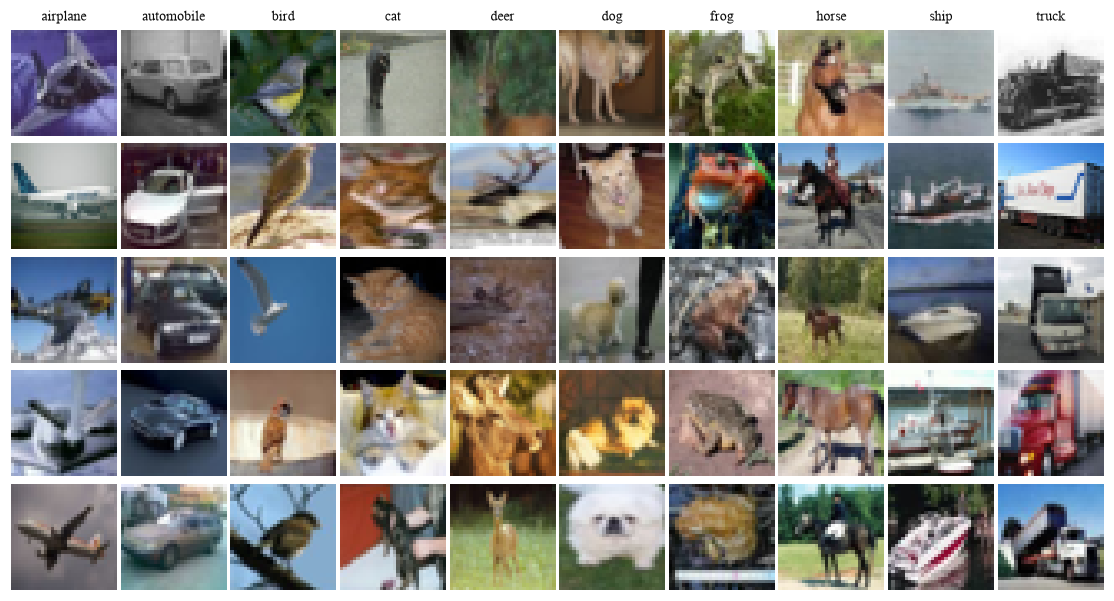

In [6]:
rng = np.random.default_rng(SEMILLA)
fig, ejes = plt.subplots(5, 10, figsize=(10, 5.4))
for j, clase in enumerate(CLASES):
    indices = rng.choice(np.where(y_completo.numpy() == j)[0], 5, replace=False)
    for i, idx in enumerate(indices):
        ejes[i, j].imshow(X_completo[idx].permute(1, 2, 0).numpy())
        ejes[i, j].axis('off')
    ejes[0, j].set_title(clase, fontsize=9)
plt.tight_layout(pad=0.3)
plt.savefig('figuras/ejemplos_por_clase.png')
plt.show()

#### ¿Qué pares de clases se espera que sean más difíciles de distinguir y por qué?

Gato y perro: comparten forma, pelaje y pose, y a 32×32 se pierden los rasgos de la cara que los separan. Automóvil y camión: ambos son vehículos con ruedas vistos de lado o de frente, con colores parecidos. Venado y caballo: cuadrúpedos de color café sobre fondos verdes. Avión y barco, o avión y pájaro: fondos azules de cielo o agua y siluetas pequeñas. En estos pares la clase depende de detalles finos que la baja resolución elimina.

### 2.4 Pipelines de preprocesamiento

Cada pipeline recibe un lote uint8 en GPU, aplica augmentation solo en entrenamiento, redimensiona si hace falta y normaliza. La CNN desde cero trabaja a 32×32 con las estadísticas de CIFAR-10. VGG-16 recibe 224×224 (interpolación bilineal) con la normalización de ImageNet. `weights.transforms()` de VGG-16 redimensiona a 256 y recorta el centro a 224; con imágenes de 32×32 ese recorte eliminaría bordes, por eso se redimensiona directo a 224. El resultado equivale a `transforms.v2.Compose([RandomCrop(32, padding=4, padding_mode='reflect'), RandomHorizontalFlip(), Resize(224), ToDtype(torch.float32, scale=True), Normalize(media, std)])`, pero ejecutado por lotes en GPU para no depender de la CPU.

In [7]:
def recorte_aleatorio(x, relleno=4):
    """RandomCrop con relleno reflejado; cada imagen del lote recibe un desplazamiento distinto."""
    n, c, h, w = x.shape
    xp = F.pad(x, (relleno,) * 4, mode='reflect')
    di = torch.randint(0, 2 * relleno + 1, (n,), device=x.device)
    dj = torch.randint(0, 2 * relleno + 1, (n,), device=x.device)
    filas = di[:, None] + torch.arange(h, device=x.device)
    cols = dj[:, None] + torch.arange(w, device=x.device)
    idx_n = torch.arange(n, device=x.device)[:, None, None, None]
    idx_c = torch.arange(c, device=x.device)[None, :, None, None]
    return xp[idx_n, idx_c, filas[:, None, :, None], cols[:, None, None, :]]


def volteo_horizontal(x, p=0.5):
    """RandomHorizontalFlip por imagen."""
    mascara = torch.rand(x.shape[0], device=x.device) < p
    return torch.where(mascara[:, None, None, None], x.flip(3), x)


class Pipeline:
    """Preprocesamiento por lotes en GPU: augmentation opcional, redimensionamiento y normalización."""

    def __init__(self, resolucion, media, std, augmentation):
        self.resolucion = resolucion
        self.media = media.view(1, 3, 1, 1).to(dispositivo)
        self.std = std.view(1, 3, 1, 1).to(dispositivo)
        self.augmentation = augmentation

    def __call__(self, x, entrenamiento):
        x = x.to(dispositivo, non_blocking=True).float().div_(255)
        if entrenamiento and self.augmentation:
            x = volteo_horizontal(recorte_aleatorio(x))
        if x.shape[-1] != self.resolucion:
            x = F.interpolate(x, size=(self.resolucion, self.resolucion), mode='bilinear', align_corners=False)
        x = (x - self.media) / self.std
        return x.contiguous(memory_format=torch.channels_last)

    def desnormalizar(self, x):
        return (x * self.std + self.media).clamp(0, 1)


RES_VGG = 224
pipeline_cnn = Pipeline(32, MEDIA_CIFAR, STD_CIFAR, augmentation=True)
pipeline_vgg = Pipeline(RES_VGG, MEDIA_IMAGENET, STD_IMAGENET, augmentation=True)

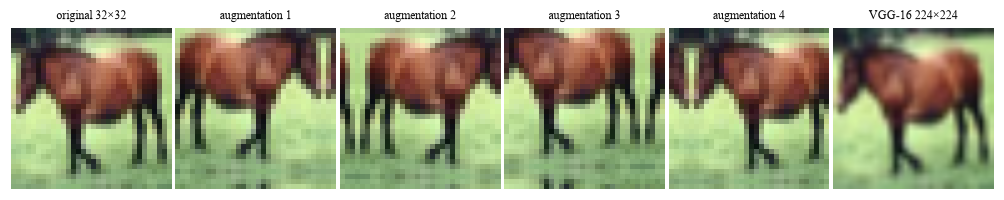

In [8]:
# Efecto de los pipelines sobre una imagen: original, cuatro versiones aumentadas y entrada de VGG-16
torch.manual_seed(1)
ejemplo = X_completo[7:8].repeat(4, 1, 1, 1)
aumentadas = pipeline_cnn.desnormalizar(pipeline_cnn(ejemplo, entrenamiento=True))
entrada_vgg = pipeline_vgg.desnormalizar(pipeline_vgg(ejemplo[:1], entrenamiento=False))

fig, ejes = plt.subplots(1, 6, figsize=(9, 1.8))
paneles = [X_completo[7].float() / 255] + [a.cpu() for a in aumentadas] + [entrada_vgg[0].cpu()]
titulos = ['original 32×32'] + [f'augmentation {i}' for i in range(1, 5)] + [f'VGG-16 {RES_VGG}×{RES_VGG}']
for ax, img, titulo in zip(ejes, paneles, titulos):
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(titulo)
    ax.axis('off')
plt.tight_layout(pad=0.3)
plt.show()

In [9]:
# Costo de VGG-16 según la resolución de entrada (solo arquitectura, sin pesos)
vgg_conteo = models.vgg16()
filas = []
for r in (32, 64, 112, 128, 224):
    s = summary(vgg_conteo, input_size=(1, 3, r, r), verbose=0, device='cpu')
    macs_conv = sum(c.macs for c in s.summary_list if c.class_name == 'Conv2d')
    filas.append({'resolución': f'{r}×{r}', 'píxeles por canal': r * r, 'factor vs 32×32': r * r / 1024,
                  'GMACs convoluciones': macs_conv / 1e9, 'GMACs totales': s.total_mult_adds / 1e9})
del vgg_conteo
tabla_resolucion = pd.DataFrame(filas).round(3)
tabla_resolucion

,resolución,píxeles por canal,factor vs 32×32,GMACs convoluciones,GMACs totales
0,32×32,1024,1.00,0.313,0.437
1,64×64,4096,4.00,1.254,1.378
2,112×112,12544,12.25,3.840,3.964
3,128×128,16384,16.00,5.016,5.139
4,224×224,50176,49.00,15.360,15.484


#### ¿Qué transformaciones de preprocesamiento necesita cada modelo? ¿Qué pasa con el número de píxeles y con el cómputo al pasar de 32×32 a 224×224?

La CNN desde cero necesita convertir a float en [0, 1] y normalizar con la media y desviación de CIFAR-10, a resolución nativa. VGG-16 necesita redimensionar a 224×224 y normalizar con las estadísticas de ImageNet, porque sus filtros se entrenaron con objetos de ese tamaño y esa escala de valores. Al pasar de 32×32 a 224×224 los píxeles por canal suben de 1,024 a 50,176, un factor de 49. Cada convolución aplica su kernel en cada posición, así que su costo crece en la misma proporción: las convoluciones de VGG-16 pasan de 0.31 a 15.36 GMACs por imagen. El clasificador no cambia porque `AdaptiveAvgPool2d` fija la salida en 512×7×7. La memoria de activaciones también crece 49 veces.

### 2.5 Data augmentation

#### ¿Qué técnicas de data augmentation se usan y por qué? ¿Por qué se aplican solo al conjunto de entrenamiento?

Se usa recorte aleatorio de 32×32 con relleno reflejado de 4 píxeles y volteo horizontal con probabilidad 0.5. En CIFAR-10 el objeto aparece en posiciones distintas y la clase no cambia al voltear la imagen de izquierda a derecha, así que ambas transformaciones generan ejemplos válidos y reducen el overfitting. No se usa volteo vertical porque un barco o un caballo invertido no pertenece a la distribución real. La augmentation se aplica solo en entrenamiento porque validación y test deben medir el desempeño sobre imágenes reales y de forma determinista; si se aplicara ahí, las métricas cambiarían entre corridas y no reflejarían los datos que verá el modelo en producción. En VGG-16 la augmentation se aplica a 32×32 antes de redimensionar, lo que equivale a hacerlo después y cuesta menos.

### 2.6 División entrenamiento / validación

El conjunto de entrenamiento original se divide en 45,000 imágenes de entrenamiento y 5,000 de validación, estratificado por clase. El test oficial de 10,000 imágenes se reserva para la evaluación final. También se reserva un subconjunto estratificado del 10 % del entrenamiento (4,500 imágenes) para la sección 4.1. Los tensores se copian una vez a la GPU.

In [10]:
etiquetas = y_completo.numpy()
idx_train, idx_val = train_test_split(np.arange(len(etiquetas)), test_size=5000,
                                      stratify=etiquetas, random_state=SEMILLA)
idx_10, _ = train_test_split(idx_train, train_size=0.10, stratify=etiquetas[idx_train], random_state=SEMILLA)

X_train, y_train = X_completo[idx_train].to(dispositivo), y_completo[idx_train].to(dispositivo)
X_val, y_val = X_completo[idx_val].to(dispositivo), y_completo[idx_val].to(dispositivo)
X_train_10, y_train_10 = X_completo[idx_10].to(dispositivo), y_completo[idx_10].to(dispositivo)
X_test_gpu, y_test_gpu = X_test.to(dispositivo), y_test.to(dispositivo)

pd.DataFrame({
    'entrenamiento': np.bincount(etiquetas[idx_train], minlength=10),
    'validación': np.bincount(etiquetas[idx_val], minlength=10),
    'entrenamiento 10 %': np.bincount(etiquetas[idx_10], minlength=10),
}, index=CLASES).T

,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
entrenamiento,4500,4500,4500,4500,4500,4500,4500,4500,4500,4500
validación,500,500,500,500,500,500,500,500,500,500
entrenamiento 10 %,450,450,450,450,450,450,450,450,450,450


## 3. Investigación: transfer learning en PyTorch

| Herramienta | Propósito | Parámetros relevantes |
|---|---|---|
| `torchvision.models.vgg16` y `VGG16_Weights` | Construye VGG-16 y carga pesos preentrenados. `VGG16_Weights.IMAGENET1K_V1` guarda los pesos de ImageNet (71.6 % top-1) y sus metadatos; `weights.transforms()` devuelve el preprocesamiento que esperan: redimensionar a 256, recorte central de 224, escala a [0, 1] y normalización de ImageNet. | `weights` (None inicializa al azar), `progress`. |
| `model.features`, `model.avgpool`, `model.classifier` | `features` es un `Sequential` con 13 convoluciones 3×3 + ReLU y 5 `MaxPool2d` que separan 5 bloques. `avgpool` es `AdaptiveAvgPool2d((7, 7))`: entrega 512×7×7 para cualquier resolución de entrada. `classifier` tiene tres capas lineales (25088→4096→4096→1000) con ReLU y Dropout; la última se reemplaza por una de 10 salidas. | `output_size` del pooling, `p` de Dropout, `in_features`/`out_features`. |
| `requires_grad` | Si es False, autograd no calcula el gradiente del parámetro y el optimizador no lo actualiza. Para congelar un bloque se recorre `bloque.parameters()` y se asigna False; para descongelarlo, True. `module.requires_grad_(False)` hace lo mismo. | Booleano por tensor. |
| `model.train()`, `model.eval()`, `torch.no_grad()` | `train()` y `eval()` cambian el comportamiento de Dropout y BatchNorm (en eval Dropout se apaga y BatchNorm usa estadísticas acumuladas). `no_grad()` evita construir el grafo de autograd y ahorra memoria y tiempo. Son independientes: `eval()` no apaga gradientes y `no_grad()` no cambia Dropout. | `mode` de `train()`. |
| `param_groups` del optimizador | El optimizador recibe una lista de diccionarios, cada uno con sus `params` y sus hiperparámetros. Permite un learning rate menor para el backbone que para el clasificador. Los schedulers aceptan un valor por grupo. | `params`, `lr`, `weight_decay` por grupo. |
| `torchinfo.summary` | Ejecuta un forward con un tensor de ejemplo y reporta por capa la forma de salida, los parámetros totales y entrenables y las mult-adds (MACs). | `input_size`, `col_names`, `depth`, `device`. |
| `torch.cuda.max_memory_allocated()`, `torch.cuda.synchronize()` | El primero devuelve el pico de memoria ocupada por tensores desde el último `reset_peak_memory_stats()`. El segundo espera a que terminen los kernels en la GPU; como CUDA es asíncrono, se llama antes de leer el reloj para medir tiempos reales. | `device`. |

MACs y FLOPs. Una MAC (multiply-accumulate) es una multiplicación seguida de una suma, y un FLOP es una sola operación de punto flotante, así que FLOPs ≈ 2 × MACs. Varias fuentes reportan MACs con el nombre de FLOPs; la documentación de torchvision lista 15.47 GFLOPS para VGG-16, que coinciden con las 15.48 GMACs que calcula torchinfo.

Parámetros totales y entrenables. Los totales son todos los pesos del modelo y determinan la memoria y el costo de inferencia. Los entrenables son los que tienen `requires_grad=True`; determinan la memoria del optimizador y el costo del backward. Congelar capas reduce los entrenables, pero no cambia los totales ni el costo del forward.

In [11]:
pesos = VGG16_Weights.IMAGENET1K_V1
print(pesos.transforms())
print('métricas ImageNet:', pesos.meta['_metrics']['ImageNet-1K'], '| GFLOPS documentados:', pesos.meta['_ops'])

vgg = models.vgg16(weights=pesos)
print(vgg.avgpool)
print(vgg.classifier)


def indices_bloques(features):
    """Devuelve (inicio, fin) de cada bloque convolucional; cada bloque termina en un MaxPool2d."""
    bloques, inicio = [], 0
    for i, capa in enumerate(features):
        if isinstance(capa, nn.MaxPool2d):
            bloques.append((inicio, i + 1))
            inicio = i + 1
    return bloques


BLOQUES_VGG = indices_bloques(vgg.features)
for b, (ini, fin) in enumerate(BLOQUES_VGG, 1):
    convs = [c for c in vgg.features[ini:fin] if isinstance(c, nn.Conv2d)]
    print(f'bloque {b}: features[{ini}:{fin}], {len(convs)} conv, {convs[0].in_channels}->{convs[-1].out_channels} canales, '
          f'{sum(p.numel() for p in vgg.features[ini:fin].parameters()) / 1e6:.2f} M parámetros')

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)
métricas ImageNet: {'acc@1': 71.592, 'acc@5': 90.382} | GFLOPS documentados: 15.47


AdaptiveAvgPool2d(output_size=(7, 7))
Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)
bloque 1: features[0:5], 2 conv, 3->64 canales, 0.04 M parámetros
bloque 2: features[5:10], 2 conv, 64->128 canales, 0.22 M parámetros
bloque 3: features[10:17], 3 conv, 128->256 canales, 1.48 M parámetros
bloque 4: features[17:24], 3 conv, 256->512 canales, 5.90 M parámetros
bloque 5: features[24:31], 3 conv, 512->512 canales, 7.08 M parámetros


In [12]:
# Congelar todo features y revisar parámetros totales y entrenables
def contar_parametros(modelo):
    total = sum(p.numel() for p in modelo.parameters())
    entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
    return total, entrenables


vgg.classifier[6] = nn.Linear(4096, 10)
vgg.features.requires_grad_(False)
print('solo clasificador: total %d, entrenables %d' % contar_parametros(vgg))
ini, fin = BLOQUES_VGG[4]
vgg.features[ini:fin].requires_grad_(True)
print('bloque 5 + clasificador: total %d, entrenables %d' % contar_parametros(vgg))

# Grupos de parámetros con learning rates distintos
optimizador_demo = torch.optim.AdamW([
    {'params': [p for p in vgg.classifier.parameters() if p.requires_grad], 'lr': 1e-4},
    {'params': [p for p in vgg.features.parameters() if p.requires_grad], 'lr': 1e-5},
])
print([(len(g['params']), g['lr']) for g in optimizador_demo.param_groups])

solo clasificador: total 134301514, entrenables 119586826
bloque 5 + clasificador: total 134301514, entrenables 126666250
[(6, 0.0001), (6, 1e-05)]


In [13]:
# Resumen con torchinfo (parámetros y MACs por capa) y medición de memoria y tiempo de un forward en GPU
print(summary(vgg, input_size=(1, 3, 224, 224), col_names=('output_size', 'num_params', 'trainable', 'mult_adds'),
              depth=2, device=dispositivo, verbose=0))

vgg = vgg.to(dispositivo).eval()
x_demo = torch.randn(64, 3, 224, 224, device=dispositivo)
torch.cuda.reset_peak_memory_stats()
with torch.no_grad():
    vgg(x_demo)
    torch.cuda.synchronize()
    inicio = time.perf_counter()
    vgg(x_demo)
    torch.cuda.synchronize()
print(f'forward de 64 imágenes: {(time.perf_counter() - inicio) * 1000:.1f} ms, '
      f'memoria pico {torch.cuda.max_memory_allocated() / 2**30:.2f} GB')
del vgg, x_demo, optimizador_demo
torch.cuda.empty_cache()

Layer (type:depth-idx)                   Output Shape              Param #                   Trainable                 Mult-Adds
VGG                                      [1, 10]                   --                        Partial                   --
├─Sequential: 1-1                        [1, 512, 7, 7]            --                        Partial                   --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         (1,792)                   False                     89,915,392
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --                        --                        --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         (36,928)                  False                     1,852,899,328
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --                        --                        --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --                        --                        -

forward de 64 imágenes: 155.2 ms, memoria pico 6.29 GB


## 4. Construcción y entrenamiento de los modelos

### Definición de los modelos

La CNN desde cero apila bloques de dos convoluciones 3×3 con BatchNorm y ReLU, seguidas de MaxPool y Dropout2d. Termina con average pooling global, Dropout y una capa lineal de 10 salidas. Las variantes de VGG-16 cargan los pesos de ImageNet, reemplazan la última capa del clasificador por `Linear(4096, 10)` y congelan `features` excepto los últimos k bloques (k = 0 para feature extractor).

In [14]:
class CNNDesdeCero(nn.Module):
    def __init__(self, anchos=(64, 128, 256), dropout_conv=0.1, dropout_fc=0.3, num_clases=10):
        super().__init__()
        capas, c_ent = [], 3
        for c in anchos:
            capas += [nn.Conv2d(c_ent, c, 3, padding=1, bias=False), nn.BatchNorm2d(c), nn.ReLU(inplace=True),
                      nn.Conv2d(c, c, 3, padding=1, bias=False), nn.BatchNorm2d(c), nn.ReLU(inplace=True),
                      nn.MaxPool2d(2), nn.Dropout2d(dropout_conv)]
            c_ent = c
        self.features = nn.Sequential(*capas)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(dropout_fc), nn.Linear(c_ent, num_clases))

    def forward(self, x):
        return self.classifier(self.avgpool(self.features(x)))


def crear_vgg16(bloques_descongelados=0, dropout_fc=0.5, num_clases=10):
    modelo = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
    modelo.classifier[6] = nn.Linear(4096, num_clases)
    modelo.classifier[2].p = modelo.classifier[5].p = dropout_fc
    modelo.features.requires_grad_(False)
    for ini, fin in BLOQUES_VGG[len(BLOQUES_VGG) - bloques_descongelados:]:
        modelo.features[ini:fin].requires_grad_(True)
    return modelo


def construir_modelo(cfg):
    if cfg['tipo'] == 'cnn':
        modelo = CNNDesdeCero(cfg['anchos'], cfg['dropout_conv'], cfg['dropout_fc'])
    else:
        modelo = crear_vgg16(cfg['bloques_descongelados'], cfg['dropout_fc'])
    return modelo.to(dispositivo, memory_format=torch.channels_last)


def crear_pipeline(cfg):
    if cfg['tipo'] == 'cnn':
        return Pipeline(32, MEDIA_CIFAR, STD_CIFAR, cfg['augmentation'])
    return Pipeline(cfg['resolucion'], MEDIA_IMAGENET, STD_IMAGENET, cfg['augmentation'])


def crear_optimizador(modelo, cfg):
    """AdamW con un grupo para el clasificador y otro para el backbone entrenable."""
    cabeza = [p for p in modelo.classifier.parameters() if p.requires_grad]
    cuerpo = [p for p in modelo.features.parameters() if p.requires_grad]
    grupos = [{'params': cabeza, 'lr': cfg['lr']}]
    if cuerpo:
        grupos.append({'params': cuerpo, 'lr': cfg.get('lr_backbone', cfg['lr'])})
    return torch.optim.AdamW(grupos, weight_decay=cfg['weight_decay'])

### Entrenamiento, evaluación y registro

Cada iteración entrena con AdamW y OneCycleLR (un learning rate máximo por grupo), en precisión mixta bfloat16. Al final de cada epoch se calcula la pérdida y las métricas macro sobre validación. Se guarda el estado de la epoch con mejor F1 de validación. El tiempo por epoch mide solo la fase de entrenamiento, con `torch.cuda.synchronize()` antes de leer el reloj. La memoria pico se toma de `torch.cuda.max_memory_allocated()` durante la fase de entrenamiento de cada epoch y se reporta el máximo desde la epoch 2, porque la primera incluye la memoria temporal del autotuning de cuDNN.

In [15]:
def iterar_lotes(X, y, tam_lote, mezclar):
    orden = torch.randperm(len(X), device=X.device) if mezclar else torch.arange(len(X), device=X.device)
    for i in range(0, len(X), tam_lote):
        idx = orden[i:i + tam_lote]
        yield X[idx], y[idx]


def entrenar_epoch(modelo, pipeline, X, y, optimizador, programador, criterio, tam_lote):
    modelo.train()
    suma, n = torch.zeros((), device=dispositivo), 0
    for xb, yb in iterar_lotes(X, y, tam_lote, mezclar=True):
        xb = pipeline(xb, entrenamiento=True)
        with torch.autocast('cuda', dtype=torch.bfloat16):
            perdida = criterio(modelo(xb), yb)
        optimizador.zero_grad(set_to_none=True)
        perdida.backward()
        optimizador.step()
        programador.step()
        suma += perdida.detach() * len(yb)
        n += len(yb)
    return (suma / n).item()


@torch.no_grad()
def evaluar(modelo, pipeline, X, y, criterio, tam_lote=250):
    modelo.eval()
    logits = []
    for xb, _ in iterar_lotes(X, y, tam_lote, mezclar=False):
        with torch.autocast('cuda', dtype=torch.bfloat16):
            logits.append(modelo(pipeline(xb, entrenamiento=False)).float())
    logits = torch.cat(logits)
    return criterio(logits, y).item(), logits.argmax(1).cpu().numpy()


def calcular_metricas(y_real, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(y_real, y_pred, average='macro', zero_division=0)
    return {'accuracy': accuracy_score(y_real, y_pred), 'precision': precision, 'recall': recall, 'f1': f1}


def ejecutar_iteracion(cfg, X_tr, y_tr, X_va, y_va):
    fijar_semilla()
    modelo = construir_modelo(cfg)
    pipeline = crear_pipeline(cfg)
    criterio = nn.CrossEntropyLoss(label_smoothing=cfg['label_smoothing'])
    optimizador = crear_optimizador(modelo, cfg)
    pasos = math.ceil(len(X_tr) / cfg['tam_lote'])
    programador = torch.optim.lr_scheduler.OneCycleLR(
        optimizador, max_lr=[g['lr'] for g in optimizador.param_groups],
        total_steps=cfg['epochs'] * pasos, pct_start=0.2)
    total, entrenables = contar_parametros(modelo)
    y_va_np = y_va.cpu().numpy()
    historial, mejor, mejor_estado = [], None, None
    torch.cuda.empty_cache()
    for epoch in range(1, cfg['epochs'] + 1):
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
        inicio = time.perf_counter()
        perdida_train = entrenar_epoch(modelo, pipeline, X_tr, y_tr, optimizador, programador, criterio, cfg['tam_lote'])
        torch.cuda.synchronize()
        tiempo = time.perf_counter() - inicio
        memoria = torch.cuda.max_memory_allocated() / 2**30
        perdida_val, pred = evaluar(modelo, pipeline, X_va, y_va, criterio)
        fila = {'epoch': epoch, 'perdida_train': perdida_train, 'perdida_val': perdida_val, 'tiempo_epoch': tiempo,
                'memoria_gb': memoria, **calcular_metricas(y_va_np, pred)}
        historial.append(fila)
        if mejor is None or fila['f1'] > mejor['f1']:
            mejor = fila
            mejor_estado = {k: v.detach().to('cpu', copy=True) for k, v in modelo.state_dict().items()}
        print(f"{cfg['id']:>11} | epoch {epoch:2d} | train {perdida_train:.4f} | val {perdida_val:.4f} | "
              f"acc {fila['accuracy']:.4f} | f1 {fila['f1']:.4f} | {tiempo:5.1f} s")
    registro = {
        'id': cfg['id'], 'modelo': cfg['modelo'], 'config': cfg,
        'params_totales': total, 'params_entrenables': entrenables, 'mejor_epoch': mejor['epoch'],
        **{k: mejor[k] for k in ('accuracy', 'precision', 'recall', 'f1')},
        'tiempo_epoch': float(np.mean([h['tiempo_epoch'] for h in historial])),
        'tiempo_total': float(sum(h['tiempo_epoch'] for h in historial)),
        # La primera epoch incluye el autotuning de cuDNN, que reserva memoria temporal
        'memoria_pico_gb': max(h['memoria_gb'] for h in historial[1:] or historial),
        'historial': historial,
    }
    del modelo, optimizador, programador
    torch.cuda.empty_cache()
    return registro, mejor_estado

### Iteraciones

CNN desde cero. CNN-1 es la línea base sin regularización (3 bloques, sin augmentation, sin dropout, sin weight decay). CNN-2 duplica los canales y agrega augmentation, dropout y weight decay. CNN-3 agrega un cuarto bloque, label smoothing y más epochs.

VGG-16 feature extractor. Se entrena solo `classifier` (fc6, fc7 y la nueva capa de salida). FE-1 usa learning rate 1e-3 y FE-2 1e-4. FE-3 repite FE-2 a 112×112 para medir el efecto de la resolución.

VGG-16 fine-tuning. Clasificador con learning rate 1e-4 y backbone con uno menor. FT-1 descongela el bloque 5; FT-2 los bloques 4 y 5; FT-3 los bloques 4 y 5 con learning rate de backbone 5e-5; FT-4 los bloques 3 a 5.

Todas las variantes de VGG-16 usan 224×224 salvo FE-3, así que el modelo final de feature extraction y el de fine-tuning comparten resolución.

In [16]:
BASE_CNN = dict(tipo='cnn', modelo='CNN desde cero', tam_lote=128, label_smoothing=0.0)
BASE_VGG = dict(tipo='vgg', tam_lote=128, resolucion=RES_VGG, augmentation=True, dropout_fc=0.5,
                weight_decay=1e-2, label_smoothing=0.0, epochs=8)
BASE_FE = dict(BASE_VGG, modelo='VGG-16 feature extractor', bloques_descongelados=0)
BASE_FT = dict(BASE_VGG, modelo='VGG-16 fine-tuning', lr=1e-4)

ITERACIONES = [
    dict(BASE_CNN, id='CNN-1', anchos=(32, 64, 128), dropout_conv=0.0, dropout_fc=0.0, augmentation=False,
         lr=1e-3, weight_decay=0.0, epochs=20),
    dict(BASE_CNN, id='CNN-2', anchos=(64, 128, 256), dropout_conv=0.1, dropout_fc=0.3, augmentation=True,
         lr=2e-3, weight_decay=5e-2, epochs=30),
    dict(BASE_CNN, id='CNN-3', anchos=(64, 128, 256, 512), dropout_conv=0.1, dropout_fc=0.3, augmentation=True,
         lr=2e-3, weight_decay=5e-2, label_smoothing=0.1, epochs=40),
    dict(BASE_FE, id='FE-1', lr=1e-3),
    dict(BASE_FE, id='FE-2', lr=1e-4),
    dict(BASE_FE, id='FE-3', lr=1e-4, resolucion=112),
    dict(BASE_FT, id='FT-1', bloques_descongelados=1, lr_backbone=1e-5),
    dict(BASE_FT, id='FT-2', bloques_descongelados=2, lr_backbone=1e-5),
    dict(BASE_FT, id='FT-3', bloques_descongelados=2, lr_backbone=5e-5),
    dict(BASE_FT, id='FT-4', bloques_descongelados=3, lr_backbone=1e-5),
]

In [17]:
registros, mejores = [], {}
for cfg in ITERACIONES:
    registro, estado = ejecutar_iteracion(cfg, X_train, y_train, X_val, y_val)
    registros.append(registro)
    familia = cfg['modelo']
    if familia not in mejores or registro['f1'] > mejores[familia][0]['f1']:
        mejores[familia] = (registro, estado)
    del estado
    with open('resultados/iteraciones.json', 'w', encoding='utf-8') as f:
        json.dump(registros, f, ensure_ascii=False, indent=1, default=float)
    print(f"{cfg['id']}: mejor F1 {registro['f1']:.4f} en epoch {registro['mejor_epoch']}, "
          f"{registro['tiempo_total'] / 60:.1f} min, memoria pico {registro['memoria_pico_gb']:.2f} GB\n")

      CNN-1 | epoch  1 | train 1.6804 | val 1.3392 | acc 0.5126 | f1 0.5027 |   4.3 s


      CNN-1 | epoch  2 | train 1.1579 | val 1.3985 | acc 0.5064 | f1 0.5102 |   1.6 s


      CNN-1 | epoch  3 | train 0.9056 | val 0.9916 | acc 0.6524 | f1 0.6463 |   1.7 s


      CNN-1 | epoch  4 | train 0.7353 | val 0.9754 | acc 0.6722 | f1 0.6596 |   1.6 s


      CNN-1 | epoch  5 | train 0.6104 | val 0.7505 | acc 0.7332 | f1 0.7410 |   1.6 s


...

       FT-4 | epoch  4 | train 0.1983 | val 0.2142 | acc 0.9262 | f1 0.9261 |  82.9 s


       FT-4 | epoch  5 | train 0.1479 | val 0.2080 | acc 0.9334 | f1 0.9334 |  83.8 s


       FT-4 | epoch  6 | train 0.1182 | val 0.1985 | acc 0.9394 | f1 0.9393 |  83.1 s


       FT-4 | epoch  7 | train 0.0933 | val 0.1992 | acc 0.9414 | f1 0.9413 |  83.5 s


       FT-4 | epoch  8 | train 0.0844 | val 0.1981 | acc 0.9414 | f1 0.9414 |  83.0 s
FT-4: mejor F1 0.9414 en epoch 8, 11.1 min, memoria pico 4.50 GB



### Resultados de las iteraciones

Métricas de validación en la epoch con mejor F1 macro.

In [18]:
def describir(cfg):
    if cfg['tipo'] == 'cnn':
        return (f"{len(cfg['anchos'])} bloques {list(cfg['anchos'])}, aug {'sí' if cfg['augmentation'] else 'no'}, "
                f"dropout {cfg['dropout_conv']}/{cfg['dropout_fc']}, wd {cfg['weight_decay']:g}, "
                f"LS {cfg['label_smoothing']:g}, lr {cfg['lr']:g}, {cfg['epochs']} ep")
    k = cfg['bloques_descongelados']
    entrenables = 'solo clasificador' if k == 0 else ('bloque 5' if k == 1 else f'bloques {6 - k}-5') + ' + clasificador'
    lr = f"lr {cfg['lr']:g}" + (f", lr backbone {cfg['lr_backbone']:g}" if k else '')
    return f"{cfg['resolucion']}×{cfg['resolucion']}, entrena {entrenables}, {lr}, {cfg['epochs']} ep"


tabla_iteraciones = pd.DataFrame([{
    'iteración': r['id'], 'configuración': describir(r['config']),
    'params totales (M)': r['params_totales'] / 1e6, 'params entrenables (M)': r['params_entrenables'] / 1e6,
    'mejor epoch': r['mejor_epoch'], 'accuracy': r['accuracy'], 'precision': r['precision'],
    'recall': r['recall'], 'F1': r['f1'], 's/epoch': r['tiempo_epoch'],
    'tiempo total (min)': r['tiempo_total'] / 60, 'memoria pico (GB)': r['memoria_pico_gb'],
} for r in registros])
tabla_iteraciones.to_csv('resultados/tabla_iteraciones.csv', index=False, encoding='utf-8')
pd.set_option('display.max_colwidth', 120)
tabla_iteraciones.round(4)

,iteración,configuración,params totales (M),params entrenables (M),mejor epoch,accuracy,precision,recall,F1,s/epoch,tiempo total (min),memoria pico (GB)
0,CNN-1,"3 bloques [32, 64, 128], aug no, dropout 0.0/0.0, wd 0, LS 0, lr 0.001, 20 ep",0.2887,0.2887,17,0.8570,0.8581,0.8570,0.8573,1.7919,0.5973,0.7856
1,CNN-2,"3 bloques [64, 128, 256], aug sí, dropout 0.1/0.3, wd 0.05, LS 0, lr 0.002, 30 ep",1.1489,1.1489,28,0.9188,0.9190,0.9188,0.9188,2.0659,1.0329,0.8737
2,CNN-3,"4 bloques [64, 128, 256, 512], aug sí, dropout 0.1/0.3, wd 0.05, LS 0.1, lr 0.002, 40 ep",4.6924,4.6924,36,0.9310,0.9313,0.9310,0.9310,2.6845,1.7896,0.9447
3,FE-1,"224×224, entrena solo clasificador, lr 0.001, 8 ep",134.3015,119.5868,8,0.9044,0.9048,0.9044,0.9042,48.8527,6.5137,4.3361
4,FE-2,"224×224, entrena solo clasificador, lr 0.0001, 8 ep",134.3015,119.5868,8,0.9116,0.9117,0.9116,0.9114,48.9155,6.5221,4.3366
5,FE-3,"112×112, entrena solo clasificador, lr 0.0001, 8 ep",134.3015,119.5868,8,0.8916,0.8922,0.8916,0.8915,19.6357,2.6181,3.0051
6,FT-1,"224×224, entrena bloque 5 + clasificador, lr 0.0001, lr backbone 1e-05, 8 ep",134.3015,126.6662,8,0.9246,0.9247,0.9246,0.9245,53.2911,7.1055,4.4177
7,FT-2,"224×224, entrena bloques 4-5 + clasificador, lr 0.0001, lr backbone 1e-05, 8 ep",134.3015,132.5660,8,0.9340,0.9339,0.9340,0.9339,67.7269,9.0303,4.4839
8,FT-3,"224×224, entrena bloques 4-5 + clasificador, lr 0.0001, lr backbone 5e-05, 8 ep",134.3015,132.5660,8,0.9468,0.9471,0.9468,0.9469,67.5083,9.0011,4.4836
9,FT-4,"224×224, entrena bloques 3-5 + clasificador, lr 0.0001, lr backbone 1e-05, 8 ep",134.3015,134.0414,8,0.9414,0.9415,0.9414,0.9414,83.5354,11.1381,4.5017


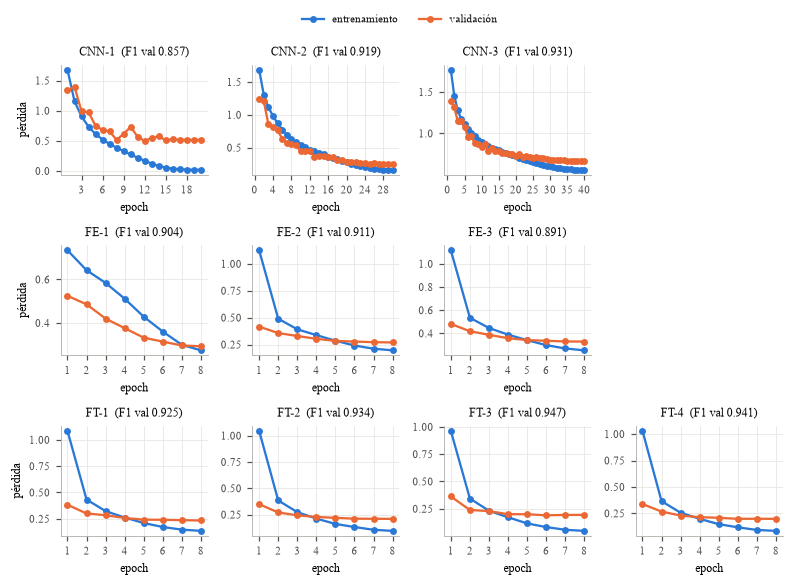

In [19]:
fig, ejes = plt.subplots(3, 4, figsize=(7.2, 5.2), sharex=False)
for fila, familia in enumerate(FAMILIAS):
    regs = [r for r in registros if r['modelo'] == familia]
    for col in range(4):
        ax = ejes[fila, col]
        if col >= len(regs):
            ax.axis('off')
            continue
        h = pd.DataFrame(regs[col]['historial'])
        ax.plot(h['epoch'], h['perdida_train'], color=COLOR_TRAIN, marker='o', label='entrenamiento')
        ax.plot(h['epoch'], h['perdida_val'], color=COLOR_VAL, marker='o', label='validación')
        ax.set_title(f"{regs[col]['id']}  (F1 val {regs[col]['f1']:.3f})")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_xlabel('epoch')
        if col == 0:
            ax.set_ylabel('pérdida')
handles, labels = ejes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.savefig('figuras/curvas_perdida.png')
plt.show()

### Evaluación final en test

Se toma la iteración con mejor F1 de validación de cada modelo y se evalúa una sola vez sobre el test oficial.

In [20]:
y_test_np = y_test_gpu.cpu().numpy()
resultados_test, matrices = {}, {}
for familia in FAMILIAS:
    registro, estado = mejores[familia]
    modelo = construir_modelo(registro['config'])
    modelo.load_state_dict(estado)
    _, pred = evaluar(modelo, crear_pipeline(registro['config']), X_test_gpu, y_test_gpu, nn.CrossEntropyLoss())
    resultados_test[familia] = calcular_metricas(y_test_np, pred)
    matrices[familia] = confusion_matrix(y_test_np, pred)
    del modelo
    torch.cuda.empty_cache()

tabla_test = pd.DataFrame(resultados_test).T
tabla_test.insert(0, 'iteración', [mejores[f][0]['id'] for f in FAMILIAS])
tabla_test.round(4)

,iteración,accuracy,precision,recall,f1
CNN desde cero,CNN-3,0.9285,0.9286,0.9285,0.9284
VGG-16 feature extractor,FE-2,0.8991,0.8988,0.8991,0.8987
VGG-16 fine-tuning,FT-3,0.9400,0.9399,0.9400,0.9399


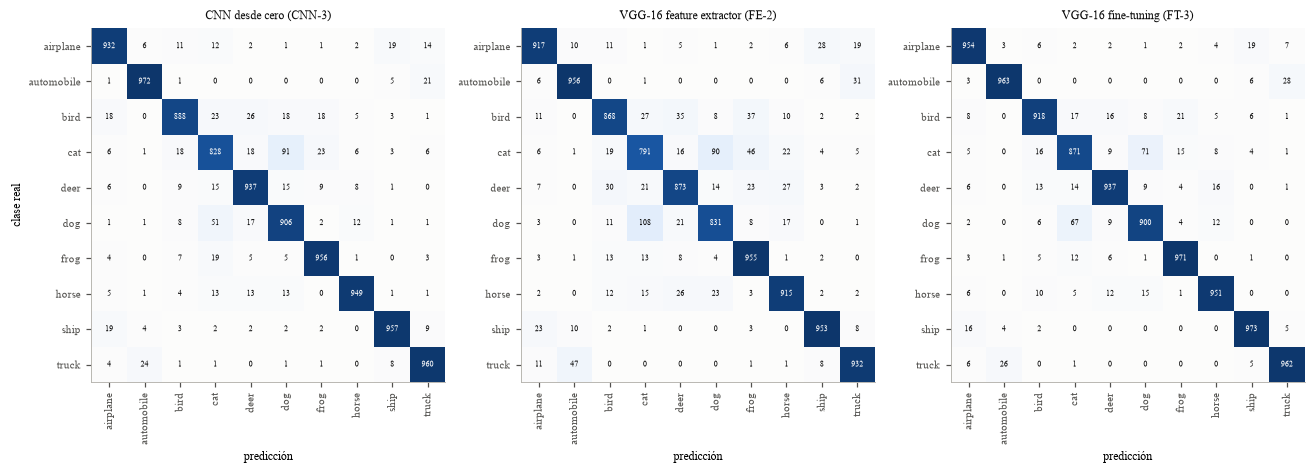

,CNN desde cero,VGG-16 feature extractor,VGG-16 fine-tuning
par 1,cat-dog (142),cat-dog (198),cat-dog (138)
par 2,automobile-truck (45),automobile-truck (78),automobile-truck (54)
par 3,cat-frog (42),bird-deer (65),airplane-ship (35)
par 4,bird-cat (41),cat-frog (59),bird-cat (33)


In [21]:
fig, ejes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, familia in zip(ejes, FAMILIAS):
    cm = matrices[familia]
    ax.imshow(cm, cmap=MAPA_AZUL)
    for i in range(10):
        for j in range(10):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=5.5,
                    color='white' if cm[i, j] > cm.max() * 0.55 else '#0b0b0b')
    ax.set_xticks(range(10), CLASES, rotation=90)
    ax.set_yticks(range(10), CLASES)
    ax.set_xlabel('predicción')
    ax.grid(False)
    ax.set_title(f"{familia} ({mejores[familia][0]['id']})")
ejes[0].set_ylabel('clase real')
plt.tight_layout()
plt.savefig('figuras/matrices_confusion.png')
plt.show()


def pares_confundidos(cm, k=4):
    pares = [(f'{CLASES[i]}-{CLASES[j]}', int(cm[i, j] + cm[j, i])) for i in range(10) for j in range(i + 1, 10)]
    return sorted(pares, key=lambda t: -t[1])[:k]


pd.DataFrame({f: [f'{p} ({n})' for p, n in pares_confundidos(matrices[f])] for f in FAMILIAS},
             index=[f'par {i}' for i in range(1, 5)])

## 4.1 Experimento adicional: efecto de la cantidad de datos

Las mejores configuraciones se entrenan de nuevo con el 10 % estratificado del entrenamiento (4,500 imágenes, 450 por clase), con los mismos hiperparámetros y epochs, y se evalúan sobre el mismo test.

In [22]:
resultados_10 = {}
for familia in FAMILIAS:
    cfg = dict(mejores[familia][0]['config'])
    cfg['id'] = cfg['id'] + ' 10%'
    registro_10, estado_10 = ejecutar_iteracion(cfg, X_train_10, y_train_10, X_val, y_val)
    modelo = construir_modelo(cfg)
    modelo.load_state_dict(estado_10)
    _, pred = evaluar(modelo, crear_pipeline(cfg), X_test_gpu, y_test_gpu, nn.CrossEntropyLoss())
    resultados_10[familia] = {**calcular_metricas(y_test_np, pred), 'registro': registro_10}
    del modelo, estado_10
    torch.cuda.empty_cache()

tabla_datos = pd.DataFrame([{
    'modelo': f, 'accuracy 100 %': resultados_test[f]['accuracy'], 'accuracy 10 %': resultados_10[f]['accuracy'],
    'F1 100 %': resultados_test[f]['f1'], 'F1 10 %': resultados_10[f]['f1'],
    'caída F1 (puntos)': (resultados_test[f]['f1'] - resultados_10[f]['f1']) * 100,
} for f in FAMILIAS])
tabla_datos.round(4)

  CNN-3 10% | epoch  1 | train 2.1334 | val 2.0595 | acc 0.2522 | f1 0.2003 |   1.8 s


  CNN-3 10% | epoch  2 | train 1.8858 | val 1.8682 | acc 0.3822 | f1 0.3739 |   0.3 s


  CNN-3 10% | epoch  3 | train 1.8118 | val 1.6843 | acc 0.4544 | f1 0.4335 |   0.3 s


  CNN-3 10% | epoch  4 | train 1.7445 | val 1.6972 | acc 0.4604 | f1 0.4217 |   0.3 s


  CNN-3 10% | epoch  5 | train 1.6954 | val 1.6125 | acc 0.4880 | f1 0.4490 |   0.3 s


...

   FT-3 10% | epoch  5 | train 0.2294 | val 0.3469 | acc 0.8858 | f1 0.8860 |   6.9 s


   FT-3 10% | epoch  6 | train 0.1590 | val 0.3528 | acc 0.8884 | f1 0.8885 |   6.9 s


   FT-3 10% | epoch  7 | train 0.1229 | val 0.3440 | acc 0.8930 | f1 0.8927 |   6.9 s


   FT-3 10% | epoch  8 | train 0.1072 | val 0.3451 | acc 0.8932 | f1 0.8930 |   6.8 s


,modelo,accuracy 100 %,accuracy 10 %,F1 100 %,F1 10 %,caída F1 (puntos)
0,CNN desde cero,0.9285,0.7989,0.9284,0.7973,13.1063
1,VGG-16 feature extractor,0.8991,0.8451,0.8987,0.8445,5.4249
2,VGG-16 fine-tuning,0.9400,0.8891,0.9399,0.8887,5.1224


## 5. Comparación de rendimiento y recursos

Las MACs por imagen se cuentan con torchinfo y FLOPs = 2 × MACs. La latencia se mide en GPU con bfloat16 de dos formas: el promedio de 300 forwards con lote de 1 imagen, y el tiempo por imagen con lotes de 256, que refleja el costo de cómputo cuando la GPU está ocupada. El cómputo de entrenamiento se estima como 2 × (MACs totales + 2 × MACs entrenables) × imágenes × epochs: cada imagen hace el forward completo y el backward, que cuesta cerca de dos forwards (gradiente de activaciones y de pesos), solo recorre las capas con parámetros entrenables. En el feature extractor el backward se limita al clasificador.

In [23]:
def contar_macs(modelo, resolucion):
    s = summary(modelo, input_size=(1, 3, resolucion, resolucion), verbose=0, device=dispositivo)
    macs_entrenables = sum(c.macs for c in s.summary_list if c.is_leaf_layer and c.trainable_params > 0)
    return s.total_mult_adds, macs_entrenables


@torch.no_grad()
def medir_latencia(modelo, resolucion, tam_lote=1, repeticiones=300):
    """Milisegundos por imagen en GPU."""
    modelo.eval()
    x = torch.randn(tam_lote, 3, resolucion, resolucion, device=dispositivo).contiguous(memory_format=torch.channels_last)
    with torch.autocast('cuda', dtype=torch.bfloat16):
        for _ in range(20):
            modelo(x)
        torch.cuda.synchronize()
        inicio = time.perf_counter()
        for _ in range(repeticiones):
            modelo(x)
        torch.cuda.synchronize()
    return (time.perf_counter() - inicio) / repeticiones / tam_lote * 1000


filas = []
for familia in FAMILIAS:
    registro = mejores[familia][0]
    cfg = registro['config']
    resolucion = 32 if cfg['tipo'] == 'cnn' else cfg['resolucion']
    modelo = construir_modelo(cfg)
    macs, macs_entrenables = contar_macs(modelo, resolucion)
    latencia = medir_latencia(modelo, resolucion)
    latencia_lote = medir_latencia(modelo, resolucion, tam_lote=256, repeticiones=20)
    del modelo
    torch.cuda.empty_cache()
    flops_entrenamiento = 2 * (macs + 2 * macs_entrenables) * len(X_train) * cfg['epochs']
    filas.append({
        'modelo': familia, 'iteración': registro['id'], 'resolución': resolucion,
        'params totales (M)': registro['params_totales'] / 1e6,
        'params entrenables (M)': registro['params_entrenables'] / 1e6,
        'GMACs/img': macs / 1e9, 'GFLOPs/img': 2 * macs / 1e9, 'GMACs entrenables/img': macs_entrenables / 1e9,
        'latencia lote 1 (ms)': latencia, 'ms/img lote 256': latencia_lote,
        's/epoch': registro['tiempo_epoch'], 'epoch mejor': registro['mejor_epoch'], 'epochs': cfg['epochs'],
        'tiempo total (min)': registro['tiempo_total'] / 60, 'memoria pico (GB)': registro['memoria_pico_gb'],
        'PFLOPs entrenamiento': flops_entrenamiento / 1e15,
        **{f'{k} test': v for k, v in resultados_test[familia].items()},
        'accuracy test 10 %': resultados_10[familia]['accuracy'], 'F1 test 10 %': resultados_10[familia]['f1'],
    })
tabla_comparacion = pd.DataFrame(filas).set_index('modelo')
tabla_comparacion.to_csv('resultados/tabla_comparacion.csv', encoding='utf-8')
tabla_comparacion.T.round(4)

modelo,CNN desde cero,VGG-16 feature extractor,VGG-16 fine-tuning
iteración,CNN-3,FE-2,FT-3
resolución,32,224,224
params totales (M),4.692426,134.301514,134.301514
params entrenables (M),4.692426,119.586826,132.566026
GMACs/img,0.209396,15.479765,15.479765
GFLOPs/img,0.418793,30.95953,30.95953
GMACs entrenables/img,0.209396,0.119587,6.132578
latencia lote 1 (ms),1.252347,1.881522,1.617252
ms/img lote 256,0.010746,0.885131,0.884318
s/epoch,2.684473,48.915471,67.50831


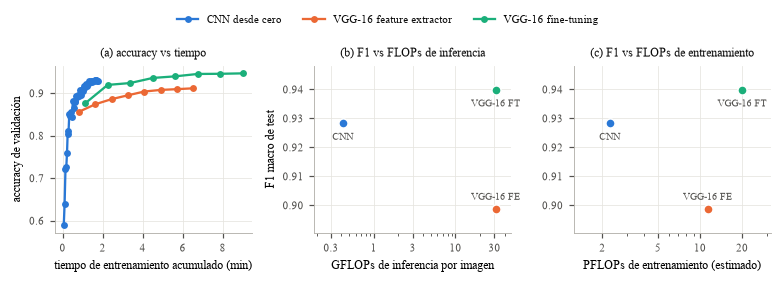

In [24]:
ETIQUETA_CORTA = dict(zip(FAMILIAS, ['CNN', 'VGG-16 FE', 'VGG-16 FT']))
DESPLAZAMIENTO = dict(zip(FAMILIAS, [(0, -11), (0, 6), (0, -11)]))
fig, ejes = plt.subplots(1, 3, figsize=(7.2, 2.4))

# (a) accuracy de validación contra tiempo de entrenamiento acumulado
ax = ejes[0]
for familia in FAMILIAS:
    h = pd.DataFrame(mejores[familia][0]['historial'])
    t = h['tiempo_epoch'].cumsum() / 60
    ax.plot(t, h['accuracy'], color=COLOR_MODELO[familia], marker='o', label=familia)
ax.set_xlabel('tiempo de entrenamiento acumulado (min)')
ax.set_ylabel('accuracy de validación')
ax.set_title('(a) accuracy vs tiempo')

# (b) y (c) F1 de test contra costo computacional, eje x logarítmico
for ax, columna, etiqueta, titulo, ticks in [
        (ejes[1], 'GFLOPs/img', 'GFLOPs de inferencia por imagen', '(b) F1 vs FLOPs de inferencia', [0.3, 1, 3, 10, 30]),
        (ejes[2], 'PFLOPs entrenamiento', 'PFLOPs de entrenamiento (estimado)', '(c) F1 vs FLOPs de entrenamiento', [2, 5, 10, 20])]:
    for familia in FAMILIAS:
        fila = tabla_comparacion.loc[familia]
        ax.scatter(fila[columna], fila['f1 test'], s=36, color=COLOR_MODELO[familia],
                   edgecolor='white', linewidth=1, zorder=3, label=familia)
        ax.annotate(ETIQUETA_CORTA[familia], (fila[columna], fila['f1 test']), xytext=DESPLAZAMIENTO[familia],
                    textcoords='offset points', ha='center', fontsize=6.5, color='#52514e')
    ax.set_xscale('log')
    ax.set_xticks(ticks, [f'{v:g}' for v in ticks])
    ax.xaxis.set_minor_formatter(NullFormatter())
    xmin, xmax = min(ticks), max(ticks)
    ax.set_xlim(xmin / 1.6, xmax * 1.6)
    ax.margins(y=0.2)
    ax.set_xlabel(etiqueta)
    ax.set_title(titulo)
ejes[1].set_ylabel('F1 macro de test')
handles, labels = ejes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.06))
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.savefig('figuras/rendimiento_vs_recursos.png')
plt.show()

In [25]:
# Resultados en disco para el informe
with open('resultados/resumen.json', 'w', encoding='utf-8') as f:
    json.dump({
        'test': resultados_test,
        'test_10': {k: {m: v for m, v in d.items() if m != 'registro'} for k, d in resultados_10.items()},
        'registros_10': {k: d['registro'] for k, d in resultados_10.items()},
        'pares_confundidos': {f: pares_confundidos(matrices[f]) for f in FAMILIAS},
        'matrices': {f: matrices[f].tolist() for f in FAMILIAS},
        'mejores': {f: mejores[f][0]['id'] for f in FAMILIAS},
        'hardware': {'gpu': propiedades.name, 'cpu': platform.processor(), 'torch': torch.__version__},
    }, f, ensure_ascii=False, indent=1, default=float)

## 6. Discusión y análisis

#### ¿Cuál de los tres modelos obtuvo el mejor desempeño en test? ¿Qué tan grande fue la diferencia y justifica el costo adicional en parámetros, FLOPs y tiempo de entrenamiento?

VGG-16 con fine-tuning (FT-3) obtuvo 94.00 % de accuracy y F1 de 0.940. Supera a la CNN desde cero por 1.15 puntos (600 errores contra 715, 16 % menos) y al feature extractor por 4.1 puntos. A cambio usa 29 veces más parámetros, 74 veces más FLOPs por imagen, 5 veces más tiempo de entrenamiento y 83 veces más tiempo de GPU por imagen en lotes. El costo se justifica solo si cada punto de accuracy importa y hay una GPU disponible; en otro caso la CNN desde cero da un resultado cercano con una fracción de los recursos.

#### ¿Qué modelo ofrece la mejor relación entre desempeño y recursos?

La CNN desde cero. En la gráfica (a) de la sección 5 llega a 93.1 % de validación en 1.6 minutos; el fine-tuning necesita 4.5 minutos para superar ese valor y termina en 9 minutos. En las gráficas (b) y (c) la CNN queda a la izquierda con F1 de 0.928: 0.42 GFLOPs por imagen y 2.3 PFLOPs de entrenamiento, contra 31 GFLOPs y 20 PFLOPs del fine-tuning. El feature extractor queda dominado: tiene el mismo costo de inferencia que el fine-tuning y el F1 más bajo.

#### VGG-16 fue entrenada con fotografías de 224×224 y CIFAR-10 tiene imágenes de 32×32. ¿Por qué las features preentrenadas siguen siendo útiles? ¿Qué efecto tiene el redimensionamiento en el desempeño y en el costo?

Los primeros bloques detectan bordes, colores y texturas que no dependen del dataset, y los superiores combinan partes de objetos. Las 10 clases de CIFAR-10 tienen equivalentes en ImageNet (perros, gatos, aves, vehículos, barcos), así que esas features ya separan las categorías. Al redimensionar, el objeto queda con una escala parecida a la de ImageNet y el último bloque produce un mapa de 7×7 en lugar de 1×1. La interpolación no agrega información, pero el costo crece con los píxeles: 49 veces más que a 32×32. A 112×112 (FE-3) el costo baja a 3.96 GMACs y el tiempo por epoch de 48.9 a 19.6 s, pero la accuracy de validación cae de 91.2 % a 89.2 %.

#### En el fine-tuning, ¿cómo afectó el número de bloques descongelados y el learning rate del backbone? ¿Observaron señales de overfitting o de catastrophic forgetting?

Con learning rate de backbone 1e-5, cada bloque descongelado mejoró la validación: 92.5 % con el bloque 5, 93.4 % con los bloques 4-5 y 94.1 % con los bloques 3-5, mientras el tiempo por epoch subió de 53 a 68 y 84 s. Subir ese learning rate a 5e-5 con los bloques 4-5 dio 94.7 %, el mejor resultado, sin costo extra por epoch. Hay señales de overfitting: en FT-3 la pérdida de entrenamiento baja a 0.05 y la de validación se estanca en 0.19 desde la epoch 6. No hubo catastrophic forgetting: la validación subió en cada epoch y desde la primera (87.6 %) superó a la del feature extractor en la misma epoch (85.6 %).

#### Con base en el experimento de la sección 4.1, ¿cuál modelo se vio más afectado al reducir los datos? ¿Cómo se relaciona esto con lo discutido en clase sobre cuándo usar feature extraction, fine-tuning o entrenar desde cero?

La CNN desde cero: con 4,500 imágenes su F1 de test bajó de 0.928 a 0.797 (13.1 puntos). El feature extractor bajó 5.4 puntos (0.899 a 0.845) y el fine-tuning 5.1 (0.940 a 0.889). Con pocos datos el feature extractor supera a la CNN por 4.7 puntos, al revés que con el dataset completo. Esto coincide con lo visto en clase: con pocos datos y un dominio parecido al de preentrenamiento conviene feature extraction o fine-tuning con learning rate bajo; con más datos se pueden descongelar más capas; entrenar desde cero requiere muchos datos y con 45,000 imágenes ya es competitivo.

#### Analicen las matrices de confusión: ¿qué pares de clases se confunden más en cada modelo? ¿Los tres modelos cometen los mismos errores?

Gato-perro es el par más confundido en los tres modelos (142 errores en la CNN, 198 en el feature extractor y 138 en el fine-tuning), seguido de automóvil-camión (45, 78 y 54). Después cambian: la CNN confunde gato-rana (42) y pájaro-gato (41); el feature extractor, pájaro-venado (65) y gato-rana (59); el fine-tuning, avión-barco (35) y pájaro-gato (33). Los tres fallan en los pares con forma y textura parecidas que se anticiparon en la exploración, pero con frecuencias distintas: el feature extractor suma 1,009 errores, la CNN 715 y el fine-tuning 600.

#### Si tuvieran que desplegar un modelo para este problema en (a) un servidor con GPU y (b) un dispositivo móvil, ¿qué modelo elegirían en cada caso y por qué? ¿Qué arquitectura preentrenada alternativa a VGG-16 considerarían para el caso (b)?

En el servidor con GPU elegiría VGG-16 con fine-tuning: tiene el mejor F1 (0.940), tarda 1.6 ms por imagen y sus 134 M de parámetros (537 MB en float32) caben en la GPU. En el móvil elegiría la CNN desde cero: 4.7 M de parámetros (19 MB en float32), 0.42 GFLOPs por imagen y 1.15 puntos menos de accuracy. Como alternativa preentrenada para el móvil consideraría MobileNetV3-Large, que usa convoluciones depthwise separables, tiene 5.5 M de parámetros y 0.22 GMACs a 224×224, y permite hacer transfer learning con un costo que el dispositivo soporta.

## Conclusiones

1. VGG-16 con fine-tuning de los bloques 4 y 5 fue el mejor modelo en test, con 94.0 % de accuracy y F1 macro de 0.940.

2. La CNN desde cero llegó a 92.9 % en test con 29 veces menos parámetros y 74 veces menos FLOPs por imagen que VGG-16.

3. VGG-16 como feature extractor obtuvo 89.9 % en test y quedó por debajo de la CNN desde cero con el dataset completo.

4. Con el 10 % de los datos, la CNN desde cero perdió 13.1 puntos de F1 y los modelos basados en VGG-16 perdieron cerca de 5.

5. En el fine-tuning, subir el learning rate del backbone de 1e-5 a 5e-5 aportó más que descongelar el bloque 3 y no aumentó el tiempo por epoch.